In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
data = pd.read_csv(r"C:\Users\jcwvi\Desktop\INaturalist Project\INaturalistDataset.csv")


1: amount of new profiles each year
2: map observations per user vs observations over time (up vs down)
3: make a stat: "90% of native observations are by 10% of people" or something
4: plot observations per user year over year to see if people become more or less involved over time

In [2]:
#Extracting Usernames from the copyright line, since I did not scrape the username data.
#I could treat the entire photo copyright message as a unique identifier, however there are two variants depending on its protection level, so this is easier
names = data["copyright"].str[4:].str.split(", some",n=1).str.get(0)
names = names.str.split(", all",n=1).str.get(0)

contributions_per_contributor = names.value_counts()
number_contributors = len(contributions_per_contributor)
num_contributors_per_contribution_amount = contributions_per_contributor.value_counts()




In [3]:
def plot_obs_per_user_per_year():
    avgs = []
    totals = []
    user_totals =[]
    data1 = data.loc[data["observed_on"].notna()].copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)

    for i in range(2008,2025):
        #sum amount of obs each year, divide by num users
        selected = data1.loc[data1["observed_on"].str.contains(f'{i}')]
        avgs.append(len(selected)/len(selected["copyright"].value_counts()))
        totals.append(len(selected)/147718*32.6219512195122)
        user_totals.append(len(selected["copyright"].value_counts()))
    
    user_totals = [x/(max(user_totals))*32.6219512195122 for x in user_totals]
    fig, ax =plt.subplots()
    bar_width = 0.25
    plt.bar(np.arange(2008,2025)-bar_width,avgs, width=bar_width)
    plt.bar(np.arange(2008,2025),totals,width=bar_width)
    plt.bar(np.arange(2008,2025)+bar_width,user_totals,width=bar_width)
    ax.set_title("Average Number of Observations Per User Each Year vs Number of Observations vs Number of Users")
    ax.legend(["average","totals","user totals"])
    ax.set_xticks(np.arange(2008,2025))
    ax.set_xticklabels(np.arange(2008,2025))
    plt.xticks(rotation=45)
    plt.show()
    

what about the data would specifically show that user involvement has increased?
perhaps the increasing amount of users recently

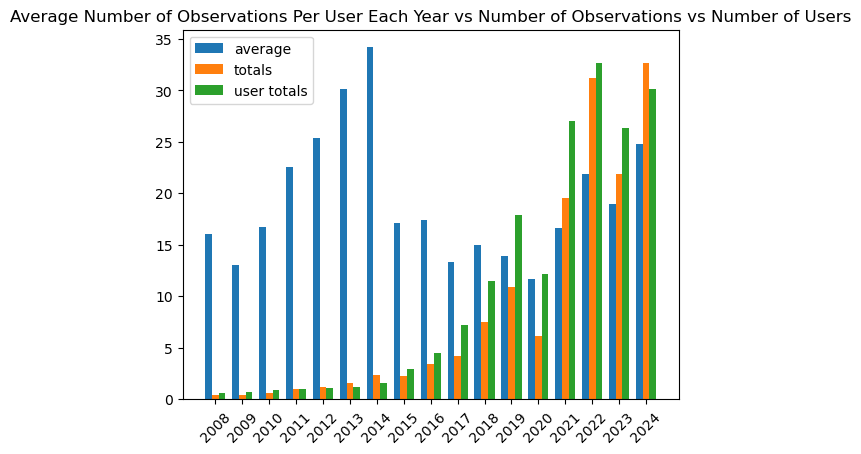

In [43]:
plot_obs_per_user_per_year()

Engagement:
Avg # of posts per user

In [29]:
def plot_active_users():
    num = [0]*(2025-2008)
    data1 = data.loc[data["observed_on"].notna()].copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)

    for i in range(2008,2025):
        #find # users who have made three observations that year
        #loop through their observations to make sure the dates of three of them are different
        selected = data1.loc[data1["observed_on"].str.contains(f'{i}')]
        users = selected["copyright"].value_counts()
        for j in users.index:
            #select all entries per each username i and check if the amount of unique dates >3
            if len(selected.loc[selected["copyright"]==j,"observed_on"].value_counts())>=3:
                num[i-2008] = num[i-2008]+1
        #amount of active users relative to amount of users, that year
        num[i-2008] = num[i-2008]/len(users)

    fig, ax = plt.subplots()
    plt.plot(np.arange(2008,2025), num,"r")
    ax.set_title("Annual Percentage of Active Users")
    ax.set_xticks(np.arange(2008,2025))
    ax.set_xticklabels(np.arange(2008,2025))
    plt.xticks(rotation=40)
    ax.set_facecolor("#faf5ee")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.savefig("activeusers.png")
    plt.show()
    return num

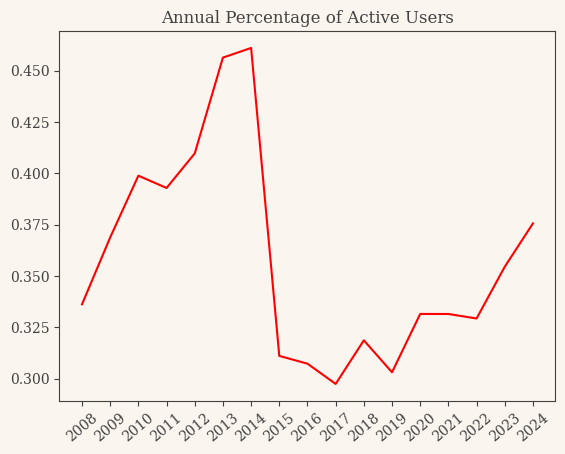

In [30]:
num = plot_active_users()

In addition to species and population-level trends, INaturalist data also has the potential to exhibit changes in community engagement with ecology. For example, you can clearly see the changes in unique users year to year:

This, however, may not be very useful on account of the rapid growth in user base seen in recent years. To really gauge whether or not there is a meaningful increase in engagement rather than a a flood of users who only used the site once or twice, you must see the change in the amount of <i>consistent</i> users. In this case, we will plot the changes in users who have made at least three observations that year on different dates, relative to the total amount of users that made observations that year:


Plot Lorentz Curve and find Gini Coefficient of users vs observations per user. Perhaps show the change of the lorentz curve each year to signify the shift from naturalists to lay people?





Lorentz: graph cumulative from lowest to highest(x) the cumulative amount of observations (y)


$$\frac{x}{n}$$


In [25]:
def plot_gini():
    values = []
    data1 = data.loc[data["observed_on"].notna()].copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)
    for i in range(2008,2025):
        observations = list(data1.loc[data1["observed_on"].str.contains(f'{i}'),"copyright"].value_counts().values)[::-1]
        observations_cumsum = np.cumsum(observations)
        observations_cumsum = observations_cumsum / max(observations_cumsum)
        most_observations = max(observations)
        x = np.arange(0.0,1.0,1/((most_observations)))
        y=x
        a=(np.trapz(observations_cumsum,dx=1/most_observations))
        b=(np.trapz(y,dx=1/most_observations))
        values.append((b-a)/b)
    fig, ax = plt.subplots()
    ax.set_xlabel("Year")
    ax.set_ylabel("Gini Index")
    ax.set_title("Gini Index Trend Since 2008")
    ax.set_facecolor("#faf5ee")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.plot(range(2008,2025),values)
    plt.savefig("Gini.png")
    plt.show()

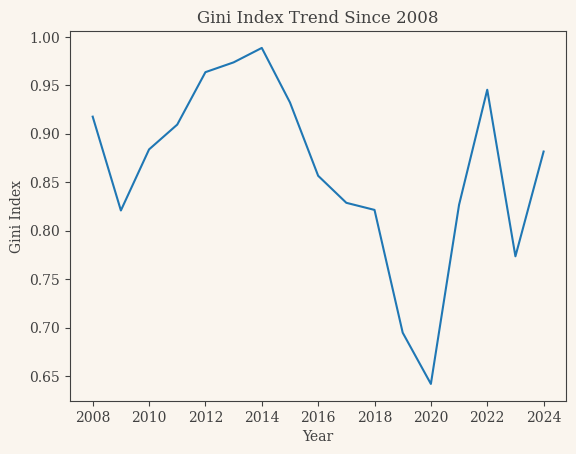

In [26]:
plot_gini()

In [133]:
def plot_lorentz():
    data1=data.copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)
    observations = list(data1["copyright"].value_counts().values)[::-1]
    observations_cumsum = np.cumsum(observations)
    observations_cumsum = observations_cumsum / max(observations_cumsum)

    x = np.arange(0.0,1.0,1/30769)
    y=x
    
    #for the Gini Index
    a=(np.trapz(observations_cumsum,dx=1/30769))
    b=(np.trapz(y,dx=1/30769))


    fig,ax = plt.subplots()
    ax.set_xlabel("Cumulative Portion of Users")
    ax.set_ylabel("Cumulative Amount of Observations")
    ax.set_title("Lorentz Curve - Cumulative Users vs Cumulative Observations")
    ax.set_facecolor("#faf5ee")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.plot(np.arange(0.0,1.0,1/30769),observations_cumsum)
    plt.plot(x,y)
    plt.fill_between(x,y,observations_cumsum, alpha = 0.2)
    plt.text(0.6,0.33,f"Gini Index:\n {round((b-a)/b,3)}", color="red", fontsize=16)
    plt.grid(True)
    plt.savefig("Lorentz.png")
    plt.show()


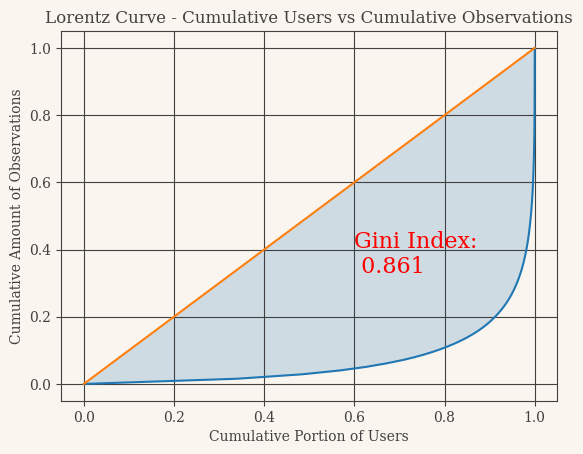

In [134]:
plot_lorentz()

In [15]:
def plot_lorentz_native():
    data1=data.copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)
    observations = list(data1["copyright"].loc[data1["establishment_means"]!="introduced"].value_counts().values)[::-1]
    observations_cumsum = np.cumsum(observations)
    observations_cumsum = observations_cumsum / max(observations_cumsum)

    x = np.arange(0.0,1.0,1/20526)
    y=x
    
    #for the Gini Index
    a=(np.trapz(observations_cumsum,dx=1/20526))
    b=(np.trapz(y,dx=1/20526))


    fig,ax = plt.subplots()
    ax.set_xlabel("Cumulative Portion of Users")
    ax.set_ylabel("Cumulative Amount of Native Species Observations")
    ax.set_title("Lorentz Curve on Native and Endemic Species")
    ax.set_facecolor("#faf5ee")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.plot(np.arange(0.0,1.0,1/20526),observations_cumsum)
    plt.plot(x,y)
    plt.fill_between(x,y,observations_cumsum, alpha = 0.2)
    plt.text(0.6,0.33,f"Gini Index:\n {round((b-a)/b,3)}", color="red", fontsize=16)
    plt.grid(True)
    plt.savefig("Lorentz.png")
    plt.show()


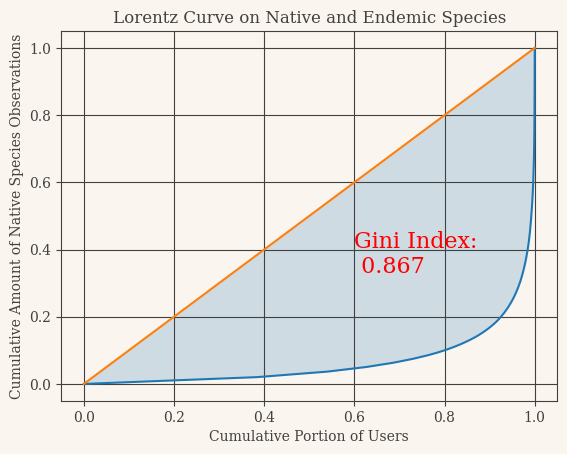

In [16]:
plot_lorentz_native()

In [ ]:
def plot_lorentz_year():
    data1=data.copy()
    data1["copyright"] = data1["copyright"].str[4:].str.split(", some",n=1).str.get(0)
    data1["copyright"] = data1["copyright"].str.split(", all",n=1).str.get(0)
    observations = list(data1["copyright"].loc[data1["observed_on"].str.contains("2014")&data1["observed_on"].notna()].value_counts().values)[::-1]
    observations_cumsum = np.cumsum(observations)
    observations_cumsum = observations_cumsum / max(observations_cumsum)

    x = np.arange(0.0,1.0,1/321)
    y=x
    
    #for the Gini Index
    a=(np.trapz(observations_cumsum,dx=1/321))
    b=(np.trapz(y,dx=1/321))

    #Plotting the Graph
    fig,ax = plt.subplots()
    ax.set_xlabel("Cumulative Portion of Users")
    ax.set_ylabel("Cumulative Amount of Native Species Observations")
    ax.set_title("Lorentz Curve on Native and Endemic Species")
    ax.set_facecolor("#faf5ee")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = '#faf5ee' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.plot(np.arange(0.0,1.0,1/321),observations_cumsum)
    plt.plot(x,y)
    plt.fill_between(x,y,observations_cumsum, alpha = 0.2)
    plt.text(0.6,0.33,f"Gini Index:\n {round((b-a)/b,3)}", color="red", fontsize=16)
    plt.grid(True)
    plt.savefig("Lorentz.png")
    plt.show()


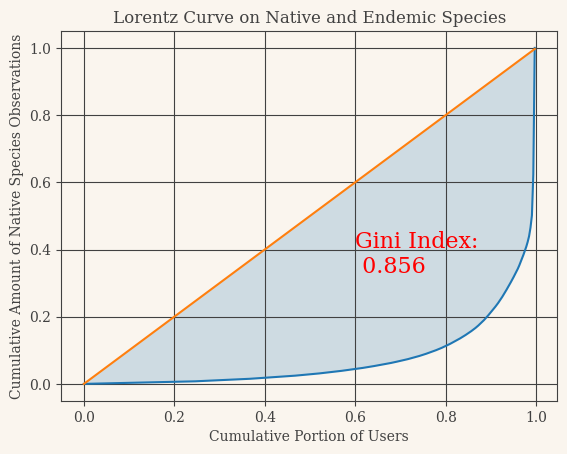

In [8]:
plot_lorentz_year()
